# Full experiment analysis

This notebook is the reproducible analysis for the pilot-scale negotiation
experiment described in the paper. The design crosses **language** (English,
Korean), **seller urgency** (none, strong), and **buyer persona**
(cooperative, neutral, headstrong) over 12 scenarios and 3 repetitions.

## Research goals

1. Test whether language changes agreement, final price, or negotiation length.
2. Test whether language changes the effects of seller urgency and buyer persona.
3. Locate those differences in buyer anchors, role-specific concessions, offer
   trajectories, and terminal offer gaps.
4. Describe whether FTA incidence and politeness realization differ by language,
   role, and condition.

## Analysis contract

- Objective actions and outcomes are primary; pragmatic labels are secondary.
- The expected factorial grid is derived from the loaded scenarios, conditions,
  and configured repetitions. Semantic `parse_error` outcomes are documented
  and excluded rather than imputed.
- Final price is analyzed only among agreements and is explicitly conditional
  on selection into agreement.
- Price is normalized as
  `(price - buyer_target) / (seller_target - buyer_target)`: 0 is the buyer
  target and 1 is the seller target. Values are never clipped.
- Scenario-balanced estimates average repetitions within scenario-condition
  cells before averaging across scenarios.
- Confidence intervals use 10,000 scenario-block bootstrap samples with seed
  42. Four headline agreement contrasts additionally use exact scenario-level
  sign-flip tests with Holm correction.
- No formal mediation analysis is performed. Three-way interactions are
  exploratory.

In [1]:
from __future__ import annotations

import hashlib
import itertools
import json
import math
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

SEED = 42
N_BOOTSTRAP = 10_000
CI_LEVEL = 0.95
MAX_TURNS = 16
N_REPETITIONS = 3
EPSILON = 1e-12

LANGUAGES = ["en", "ko"]
URGENCY_LEVELS = ["none", "strong"]
PERSONAS = ["cooperative", "neutral", "headstrong"]
ROLES = ["buyer", "seller"]
CONDITION_COLUMNS = ["language", "urgency", "persona"]
CONDITIONS = list(itertools.product(LANGUAGES, URGENCY_LEVELS, PERSONAS))
STRATEGIES = [
    "bald_on_record",
    "positive_politeness",
    "negative_politeness",
    "off_record",
]
PRICE_ACTIONS = {"offer", "counter-offer"}
TERMINAL_ACTIONS = {"accept", "reject"}
ALLOWED_ACTIONS = PRICE_ACTIONS | TERMINAL_ACTIONS
VALID_OUTCOMES = {"agreed", "abandoned", "max_turns_reached"}


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "scenarios.json").is_file() and (
            candidate / "results" / "transcripts"
        ).is_dir():
            return candidate.resolve()
    raise RuntimeError("Could not locate the repository root from the current directory")


ROOT = find_repo_root()
SCENARIOS_PATH = ROOT / "data" / "scenarios.json"
TRANSCRIPTS_DIR = ROOT / "results" / "transcripts"
JUDGED_DIR = ROOT / "results" / "judged"
OUTPUT_DIR = ROOT / "results" / "analysis"
DATA_DIR = OUTPUT_DIR / "data"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

for directory in [OUTPUT_DIR, DATA_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 220,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"Repository root: {ROOT}")
print(f"Derived outputs: {OUTPUT_DIR}")

Repository root: E:\polite-bargain
Derived outputs: E:\polite-bargain\results\analysis


## 1. Load the design and input files

The checks below distinguish malformed JSON from a completed JSON record whose
semantic outcome is `parse_error`. JSON decoding or schema failures stop the
notebook. The two known semantic failures remain visible in the exclusion table.

In [2]:
def require(condition: bool, message: str) -> None:
    if not condition:
        raise AssertionError(message)


def read_json(path: Path):
    try:
        with path.open("r", encoding="utf-8") as handle:
            return json.load(handle)
    except Exception as exc:
        raise RuntimeError(f"Failed to read JSON from {path}: {exc}") from exc


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def combined_sha256(paths: list[Path], root: Path) -> str:
    digest = hashlib.sha256()
    for path in sorted(paths):
        digest.update(path.relative_to(root).as_posix().encode("utf-8"))
        digest.update(b"\0")
        digest.update(bytes.fromhex(sha256_file(path)))
    return digest.hexdigest()


def is_finite_number(value) -> bool:
    return (
        isinstance(value, (int, float))
        and not isinstance(value, bool)
        and math.isfinite(float(value))
    )


scenarios_payload = read_json(SCENARIOS_PATH)
require(isinstance(scenarios_payload, list), "scenarios.json must contain a list")
require(len(scenarios_payload) == 12, f"Expected 12 scenarios, found {len(scenarios_payload)}")

scenario_rows = []
for index, scenario in enumerate(scenarios_payload):
    scenario_id = f"scenario-{index:02d}"
    required_fields = {
        "category",
        "title",
        "description",
        "listing_price",
        "buyer_target",
        "seller_target",
        "title_ko",
        "description_ko",
    }
    require(required_fields <= set(scenario), f"{scenario_id} is missing required fields")
    require(is_finite_number(scenario["buyer_target"]), f"Invalid buyer target in {scenario_id}")
    require(is_finite_number(scenario["seller_target"]), f"Invalid seller target in {scenario_id}")
    require(
        float(scenario["seller_target"]) > float(scenario["buyer_target"]),
        f"Non-positive bargaining span in {scenario_id}",
    )
    require(str(scenario["title_ko"]).strip(), f"Missing Korean title in {scenario_id}")
    require(str(scenario["description_ko"]).strip(), f"Missing Korean description in {scenario_id}")
    scenario_rows.append(
        {
            "scenario_id": scenario_id,
            **scenario,
            "price_span": float(scenario["seller_target"]) - float(scenario["buyer_target"]),
        }
    )

scenarios_df = pd.DataFrame(scenario_rows)
scenario_lookup = scenarios_df.set_index("scenario_id").to_dict("index")
scenario_ids = scenarios_df["scenario_id"].tolist()
expected_attempts = len(scenario_ids) * len(CONDITIONS) * N_REPETITIONS
expected_per_cell = len(scenario_ids) * N_REPETITIONS


expected_keys = {
    (scenario_id, language, urgency, persona, repetition)
    for scenario_id in scenario_ids
    for language, urgency, persona in CONDITIONS
    for repetition in range(N_REPETITIONS)
}
transcript_paths = sorted(TRANSCRIPTS_DIR.glob("*.json"))
judged_paths = sorted(JUDGED_DIR.glob("*.json"))

require(
    len(expected_keys) == expected_attempts,
    "Expected-key construction does not match the configured factorial design",
)
require(
    len(transcript_paths) == expected_attempts,
    f"Expected {expected_attempts} transcript files, found {len(transcript_paths)}",
)
print(f"Loaded design metadata for {len(scenarios_df)} scenarios")
print(f"Found {len(transcript_paths)} transcript files and {len(judged_paths)} judged files")

Loaded design metadata for 12 scenarios
Found 432 transcript files and 430 judged files


## 2. Validate transcripts, exclusions, and judge alignment

Validation covers filenames and factorial keys, role alternation, action and
price schemas, terminal outcomes, final-price consistency, basic script
compliance, and one-to-one alignment with the pragmatic annotations.

In [3]:
TRANSCRIPT_NAME = re.compile(
    r"^(scenario-\d{2})_(en|ko)-(none|strong)-(cooperative|neutral|headstrong)_rep(\d+)\.json$"
)
JUDGED_NAME = re.compile(
    r"^(scenario-\d{2})_(en|ko)-(none|strong)-(cooperative|neutral|headstrong)_rep(\d+)_judged\.json$"
)
HANGUL_RE = re.compile(r"[\uac00-\ud7a3]")


def key_from_payload(payload: dict) -> tuple[str, str, str, str, int]:
    condition_id = payload.get("condition_id")
    require(isinstance(condition_id, str), "condition_id must be a string")
    parts = condition_id.split("-")
    require(len(parts) == 3, f"Invalid condition_id: {condition_id!r}")
    language, urgency, persona = parts
    require(language in LANGUAGES, f"Unknown language: {language}")
    require(urgency in URGENCY_LEVELS, f"Unknown urgency: {urgency}")
    require(persona in PERSONAS, f"Unknown persona: {persona}")
    repetition = payload.get("repetition")
    require(
        isinstance(repetition, int) and repetition in range(N_REPETITIONS),
        f"Invalid repetition: {repetition}",
    )
    scenario_id = payload.get("scenario_id")
    require(scenario_id in scenario_lookup, f"Unknown scenario_id: {scenario_id}")
    return scenario_id, language, urgency, persona, repetition


transcripts_by_key = {}
attempt_records = []
exclusion_records = []

for path in transcript_paths:
    match = TRANSCRIPT_NAME.fullmatch(path.name)
    require(match is not None, f"Unexpected transcript filename: {path.name}")
    payload = read_json(path)
    require(isinstance(payload, dict), f"Transcript must be an object: {path.name}")
    key = key_from_payload(payload)
    filename_key = (
        match.group(1),
        match.group(2),
        match.group(3),
        match.group(4),
        int(match.group(5)),
    )
    require(key == filename_key, f"Filename/payload mismatch in {path.name}")
    require(key not in transcripts_by_key, f"Duplicate transcript key: {key}")
    transcripts_by_key[key] = (path, payload)

    outcome = payload.get("outcome")
    status = "excluded" if outcome == "parse_error" else "valid"
    attempt_records.append(
        {
            "scenario_id": key[0],
            "language": key[1],
            "urgency": key[2],
            "persona": key[3],
            "repetition": key[4],
            "transcript_file": path.name,
            "outcome": outcome,
            "analysis_status": status,
        }
    )
    if outcome == "parse_error":
        turns = payload.get("turns", [])
        terminal = turns[-1] if isinstance(turns, list) and turns else {}
        exclusion_records.append(
            {
                "transcript_file": path.name,
                "scenario_id": key[0],
                "condition_id": f"{key[1]}-{key[2]}-{key[3]}",
                "repetition": key[4],
                "reason": "semantic parse_error outcome",
                "records_in_turns": len(turns) if isinstance(turns, list) else None,
                "n_turns_field": payload.get("n_turns"),
                "terminal_error": terminal.get("error"),
            }
        )

require(set(transcripts_by_key) == expected_keys, "Transcript keys do not match the intended factorial grid")
valid_keys = {key for key, (_, payload) in transcripts_by_key.items() if payload.get("outcome") != "parse_error"}
excluded_keys = set(transcripts_by_key) - valid_keys
require(
    len(valid_keys) + len(excluded_keys) == expected_attempts,
    "Valid and excluded keys must partition the expected design grid",
)

judged_by_key = {}
for path in judged_paths:
    match = JUDGED_NAME.fullmatch(path.name)
    require(match is not None, f"Unexpected judged filename: {path.name}")
    payload = read_json(path)
    require(isinstance(payload, dict), f"Judged result must be an object: {path.name}")
    key = key_from_payload(payload)
    filename_key = (
        match.group(1),
        match.group(2),
        match.group(3),
        match.group(4),
        int(match.group(5)),
    )
    require(key == filename_key, f"Filename/payload mismatch in {path.name}")
    require(key not in judged_by_key, f"Duplicate judged key: {key}")
    judged_by_key[key] = (path, payload)

require(set(judged_by_key) == valid_keys, "Judged files must align one-to-one with valid transcripts")

valid_records = []
turn_records = []
judge_models = Counter()

for key in sorted(valid_keys):
    path, transcript = transcripts_by_key[key]
    judged_path, judged = judged_by_key[key]
    scenario_id, language, urgency, persona, repetition = key
    scenario = scenario_lookup[scenario_id]
    condition_id = f"{language}-{urgency}-{persona}"
    transcript_id = f"{scenario_id}_{condition_id}_rep{repetition}"

    require(transcript.get("outcome") in VALID_OUTCOMES, f"Invalid outcome in {path.name}")
    turns = transcript.get("turns")
    require(isinstance(turns, list) and turns, f"Missing turns in {path.name}")
    require(transcript.get("n_turns") == len(turns), f"n_turns mismatch in {path.name}")
    require(1 <= len(turns) <= MAX_TURNS, f"Invalid turn count in {path.name}")
    require(turns[0].get("role") == "seller", f"Seller must open in {path.name}")
    require(turns[0].get("action") == "offer", f"First action must be an offer in {path.name}")

    utterances = []
    for turn_index, turn in enumerate(turns):
        expected_role = "seller" if turn_index % 2 == 0 else "buyer"
        require(turn.get("role") == expected_role, f"Role alternation failed in {path.name} turn {turn_index}")
        action = turn.get("action")
        require(action in ALLOWED_ACTIONS, f"Invalid action in {path.name} turn {turn_index}")
        utterance = turn.get("utterance")
        require(isinstance(utterance, str) and utterance.strip(), f"Invalid utterance in {path.name} turn {turn_index}")
        utterances.append(utterance)
        price = turn.get("price")
        if action in PRICE_ACTIONS or action == "accept":
            require(is_finite_number(price) and float(price) > 0, f"Invalid offer price in {path.name} turn {turn_index}")
        else:
            require(price is None, f"Reject action must have null price in {path.name} turn {turn_index}")
        if action in TERMINAL_ACTIONS:
            require(turn_index == len(turns) - 1, f"Terminal action before final turn in {path.name}")

    if language == "ko":
        require(all(HANGUL_RE.search(text) for text in utterances), f"Korean script check failed in {path.name}")
    else:
        require(all(not HANGUL_RE.search(text) for text in utterances), f"English script check failed in {path.name}")

    outcome = transcript["outcome"]
    final_price = transcript.get("final_price")
    if outcome == "agreed":
        require(turns[-1]["action"] == "accept", f"Agreement must end in accept in {path.name}")
        require(is_finite_number(final_price), f"Agreement must have final_price in {path.name}")
        preceding_prices = [float(turn["price"]) for turn in turns[:-1] if turn.get("price") is not None]
        require(preceding_prices, f"Agreement has no preceding offer in {path.name}")
        require(
            math.isclose(float(turns[-1]["price"]), preceding_prices[-1], abs_tol=1e-9),
            f"Accepted price does not repeat the live offer in {path.name}",
        )
        require(
            math.isclose(float(final_price), float(turns[-1]["price"]), abs_tol=1e-9),
            f"Final price mismatch in {path.name}",
        )
        require(
            float(scenario["buyer_target"]) - EPSILON
            <= float(final_price)
            <= float(scenario["seller_target"]) + EPSILON,
            f"Agreed price lies outside the target interval in {path.name}",
        )
    elif outcome == "abandoned":
        require(turns[-1]["action"] == "reject", f"Abandonment must end in reject in {path.name}")
        require(final_price is None, f"Abandonment must have null final_price in {path.name}")
    else:
        require(len(turns) == MAX_TURNS, f"Turn-cap outcome must use {MAX_TURNS} turns in {path.name}")
        require(final_price is None, f"Turn-cap outcome must have null final_price in {path.name}")

    coded_turns = judged.get("coded_turns")
    require(isinstance(coded_turns, list), f"Missing coded_turns in {judged_path.name}")
    require(len(coded_turns) == len(turns), f"Judge/transcript length mismatch in {judged_path.name}")
    judge_model = judged.get("judge_model")
    require(isinstance(judge_model, str) and judge_model, f"Missing judge model in {judged_path.name}")
    judge_models[judge_model] += 1

    normalized_final_price = (
        (float(final_price) - float(scenario["buyer_target"])) / float(scenario["price_span"])
        if outcome == "agreed"
        else np.nan
    )
    valid_records.append(
        {
            "transcript_id": transcript_id,
            "transcript_file": path.name,
            "judged_file": judged_path.name,
            "scenario_id": scenario_id,
            "category": scenario["category"],
            "condition_id": condition_id,
            "language": language,
            "urgency": urgency,
            "persona": persona,
            "repetition": repetition,
            "outcome": outcome,
            "final_price": float(final_price) if final_price is not None else np.nan,
            "normalized_final_price": normalized_final_price,
            "n_turns": len(turns),
            "buyer_target": float(scenario["buyer_target"]),
            "seller_target": float(scenario["seller_target"]),
            "listing_price": float(scenario["listing_price"]),
            "price_span": float(scenario["price_span"]),
            "judge_model": judge_model,
        }
    )

    for turn_index, (turn, coded) in enumerate(zip(turns, coded_turns)):
        require(coded.get("turn") == turn_index, f"Judge turn index mismatch in {judged_path.name}")
        require(coded.get("role") == turn["role"], f"Judge role mismatch in {judged_path.name}")
        is_fta = coded.get("is_fta")
        require(isinstance(is_fta, bool), f"is_fta must be boolean in {judged_path.name}")
        strategy = coded.get("strategy")
        if is_fta:
            require(strategy in STRATEGIES, f"Invalid strategy in {judged_path.name}")
        else:
            require(strategy is None, f"Non-FTA strategy must be null in {judged_path.name}")

        price = float(turn["price"]) if turn.get("price") is not None else np.nan
        normalized_price = (
            (price - float(scenario["buyer_target"])) / float(scenario["price_span"])
            if math.isfinite(price)
            else np.nan
        )
        turn_records.append(
            {
                "transcript_id": transcript_id,
                "scenario_id": scenario_id,
                "condition_id": condition_id,
                "language": language,
                "urgency": urgency,
                "persona": persona,
                "repetition": repetition,
                "outcome": outcome,
                "turn_index": turn_index,
                "turn_number": turn_index + 1,
                "role": turn["role"],
                "action": turn["action"],
                "price": price,
                "normalized_price": normalized_price,
                "is_fta": is_fta,
                "strategy": strategy,
                "is_mitigated": bool(is_fta and strategy != "bald_on_record"),
                "utterance": turn["utterance"],
            }
        )

attempts_df = pd.DataFrame(attempt_records).sort_values(
    ["scenario_id", "language", "urgency", "persona", "repetition"]
).reset_index(drop=True)
exclusion_columns = [
    "transcript_file",
    "scenario_id",
    "condition_id",
    "repetition",
    "reason",
    "records_in_turns",
    "n_turns_field",
    "terminal_error",
]
exclusions_df = pd.DataFrame(exclusion_records, columns=exclusion_columns).sort_values(
    "transcript_file"
).reset_index(drop=True)
valid_df = pd.DataFrame(valid_records).sort_values(
    ["scenario_id", "language", "urgency", "persona", "repetition"]
).reset_index(drop=True)
turn_df = pd.DataFrame(turn_records).sort_values(["transcript_id", "turn_index"]).reset_index(drop=True)

require(
    len(valid_df) == len(valid_keys),
    "Valid transcript frame must contain one row per valid design key",
)
require(valid_df["transcript_id"].is_unique, "Transcript IDs must be unique")
require(len(turn_df) == int(valid_df["n_turns"].sum()), "Turn frame row count mismatch")
require(set(judge_models) == {"qwen/qwen3.7-flash"}, f"Unexpected judge models: {dict(judge_models)}")

print(f"Validated {len(valid_df)} complete transcripts and {len(turn_df)} turns")
print(f"Judge coverage: {sum(judge_models.values())} files via {next(iter(judge_models))}")

Validated 430 complete transcripts and 4580 turns
Judge coverage: 430 files via qwen/qwen3.7-flash


In [4]:
cell_attempts = (
    attempts_df.groupby(CONDITION_COLUMNS, observed=True)
    .agg(
        n_attempted=("transcript_id" if "transcript_id" in attempts_df else "transcript_file", "size"),
        n_valid=("analysis_status", lambda values: int((values == "valid").sum())),
        n_excluded=("analysis_status", lambda values: int((values == "excluded").sum())),
    )
    .reset_index()
)
condition_index = pd.MultiIndex.from_tuples(CONDITIONS, names=CONDITION_COLUMNS)
cell_attempts = (
    cell_attempts.set_index(CONDITION_COLUMNS)
    .reindex(condition_index, fill_value=0)
    .reset_index()
)

require(
    (cell_attempts["n_attempted"] == expected_per_cell).all(),
    f"Every design cell must contain {expected_per_cell} attempts",
)
require(
    (cell_attempts["n_valid"] + cell_attempts["n_excluded"] == cell_attempts["n_attempted"]).all(),
    "Valid and excluded runs must partition every design cell",
)
require(
    int(cell_attempts["n_excluded"].sum()) == len(excluded_keys),
    "Cell-level exclusion counts do not match the exclusion manifest",
)
deficient = cell_attempts.loc[
    cell_attempts["n_valid"] != expected_per_cell,
    CONDITION_COLUMNS + ["n_valid", "n_excluded"],
]

outcome_counts = valid_df["outcome"].value_counts().reindex(
    ["agreed", "abandoned", "max_turns_reached"], fill_value=0
)
qc_overview = pd.DataFrame(
    {
        "quantity": [
            "expected attempts",
            "transcript files",
            "valid transcripts",
            "semantic exclusions",
            "judged files",
            "validated turns",
            "agreements",
            "abandonments",
            "turn-cap outcomes",
        ],
        "count": [
            expected_attempts,
            len(transcript_paths),
            len(valid_df),
            len(exclusions_df),
            len(judged_paths),
            len(turn_df),
            int(outcome_counts["agreed"]),
            int(outcome_counts["abandoned"]),
            int(outcome_counts["max_turns_reached"]),
        ],
    }
)

display(qc_overview)
display(cell_attempts)
display(exclusions_df)

,quantity,count
0,expected attempts,432
1,transcript files,432
2,valid transcripts,430
3,semantic exclusions,2
4,judged files,430
5,validated turns,4580
6,agreements,279
7,abandonments,118
8,turn-cap outcomes,33


,language,urgency,persona,n_attempted,n_valid,n_excluded
0,en,none,cooperative,36,36,0
1,en,none,neutral,36,36,0
2,en,none,headstrong,36,36,0
3,en,strong,cooperative,36,36,0
4,en,strong,neutral,36,36,0
5,en,strong,headstrong,36,34,2
6,ko,none,cooperative,36,36,0
7,ko,none,neutral,36,36,0
8,ko,none,headstrong,36,36,0
9,ko,strong,cooperative,36,36,0


,transcript_file,scenario_id,condition_id,repetition,reason,records_in_turns,n_turns_field,terminal_error
0,scenario-00_en-strong-headstrong_rep1.json,scenario-00,en-strong-headstrong,1,semantic parse_error outcome,6,0,Expecting property name enclosed in double quo...
1,scenario-06_en-strong-headstrong_rep0.json,scenario-06,en-strong-headstrong,0,semantic parse_error outcome,15,0,"No JSON object found in response: ""Refusing to..."


## 3. Construct transcript-level metrics

Price-bearing actions are `offer` and `counter-offer`; accepts and rejects do
not create new price points. A buyer concession is an increase from that
buyer's previous offer. A seller concession is a decrease from that seller's
previous ask. Gross concession sums movement toward the opponent, hardening
sums movement away, and net concession compares the role's last and first
price-bearing actions.

In [5]:
def offer_metrics(group: pd.DataFrame, role: str) -> dict:
    offers = group.loc[
        (group["role"] == role)
        & group["action"].isin(PRICE_ACTIONS)
        & group["normalized_price"].notna()
    ].sort_values("turn_index")
    values = offers["normalized_price"].to_numpy(dtype=float)
    prefix = f"{role}_"
    require(len(values) >= 1, f"Every {role} must make at least one price-bearing action")

    direction = 1.0 if role == "buyer" else -1.0
    directed_steps = direction * np.diff(values)
    positive = np.clip(directed_steps, 0.0, None)
    hardening = np.clip(-directed_steps, 0.0, None)
    positive_mask = directed_steps > EPSILON
    hardening_mask = directed_steps < -EPSILON
    opportunities = max(len(values) - 1, 0)

    if positive_mask.any():
        first_step_index = int(np.flatnonzero(positive_mask)[0]) + 1
        first_turn = int(offers.iloc[first_step_index]["turn_number"])
        n_turns = int(group["turn_number"].max())
        first_progress = (first_turn - 1) / max(n_turns - 1, 1)
    else:
        first_turn = np.nan
        first_progress = np.nan

    return {
        prefix + "offer_count": int(len(values)),
        prefix + "first_offer_norm": float(values[0]),
        prefix + "last_offer_norm": float(values[-1]),
        prefix + "concession_opportunities": opportunities,
        prefix + "concession_count": int(positive_mask.sum()),
        prefix + "concession_rate": float(positive_mask.mean()) if opportunities else np.nan,
        prefix + "gross_concession_norm": float(positive.sum()),
        prefix + "net_concession_norm": float(direction * (values[-1] - values[0])),
        prefix + "hardening_count": int(hardening_mask.sum()),
        prefix + "hardening_norm": float(hardening.sum()),
        prefix + "mean_concession_norm": (
            float(positive[positive_mask].mean()) if positive_mask.any() else np.nan
        ),
        prefix + "first_concession_turn": first_turn,
        prefix + "first_concession_progress": first_progress,
    }


def pragmatic_metrics(group: pd.DataFrame, role: str) -> dict:
    role_group = group if role == "overall" else group.loc[group["role"] == role]
    n_turns = len(role_group)
    fta_count = int(role_group["is_fta"].sum())
    mitigated_count = int(role_group["is_mitigated"].sum())
    result = {
        "n_role_turns": n_turns,
        "fta_count": fta_count,
        "fta_rate": fta_count / n_turns if n_turns else np.nan,
        "mitigated_fta_count": mitigated_count,
        "mitigation_rate": mitigated_count / fta_count if fta_count else np.nan,
    }
    for strategy in STRATEGIES:
        count = int((role_group["strategy"] == strategy).sum())
        result[f"{strategy}_count"] = count
        result[f"{strategy}_share"] = count / fta_count if fta_count else np.nan
    return result


transcript_records = []
pragmatic_records = []

for meta in valid_df.to_dict("records"):
    transcript_id = meta["transcript_id"]
    group = turn_df.loc[turn_df["transcript_id"] == transcript_id].copy()
    outcome = meta["outcome"]
    record = {
        **meta,
        "agreed": int(outcome == "agreed"),
        "abandoned": int(outcome == "abandoned"),
        "max_turn": int(outcome == "max_turns_reached"),
        "terminal_action": group.iloc[-1]["action"],
        "terminal_actor": group.iloc[-1]["role"],
        "accepted_by": group.iloc[-1]["role"] if outcome == "agreed" else None,
        "walked_away_by": group.iloc[-1]["role"] if outcome == "abandoned" else None,
    }
    for role in ROLES:
        record.update(offer_metrics(group, role))
        role_pragmatics = pragmatic_metrics(group, role)
        for name, value in role_pragmatics.items():
            record[f"{role}_{name}"] = value
        pragmatic_records.append(
            {
                "transcript_id": transcript_id,
                "scenario_id": meta["scenario_id"],
                "condition_id": meta["condition_id"],
                "language": meta["language"],
                "urgency": meta["urgency"],
                "persona": meta["persona"],
                "repetition": meta["repetition"],
                "outcome": outcome,
                "agreed": int(outcome == "agreed"),
                "role": role,
                **role_pragmatics,
            }
        )

    pragmatic_records.append(
        {
            "transcript_id": transcript_id,
            "scenario_id": meta["scenario_id"],
            "condition_id": meta["condition_id"],
            "language": meta["language"],
            "urgency": meta["urgency"],
            "persona": meta["persona"],
            "repetition": meta["repetition"],
            "outcome": outcome,
            "agreed": int(outcome == "agreed"),
            "role": "overall",
            **pragmatic_metrics(group, "overall"),
        }
    )

    record["terminal_gap_norm"] = record["seller_last_offer_norm"] - record["buyer_last_offer_norm"]
    transcript_records.append(record)

transcript_df = pd.DataFrame(transcript_records).sort_values(
    ["scenario_id", "language", "urgency", "persona", "repetition"]
).reset_index(drop=True)
pragmatic_df = pd.DataFrame(pragmatic_records).sort_values(
    ["scenario_id", "language", "urgency", "persona", "repetition", "role"]
).reset_index(drop=True)

require(
    len(transcript_df) == len(valid_df),
    "Transcript metric frame must contain one row per valid transcript",
)
require(np.allclose(transcript_df["seller_first_offer_norm"], 1.0), "Seller openings should equal the seller target")
require(
    transcript_df.loc[transcript_df["agreed"] == 1, "normalized_final_price"].between(0, 1).all(),
    "Agreed normalized prices must lie in the target interval",
)
require(
    len(pragmatic_df) == len(valid_df) * (len(ROLES) + 1),
    "Pragmatic frame should contain buyer, seller, and overall rows per transcript",
)

display(
    transcript_df[
        [
            "transcript_id",
            "outcome",
            "n_turns",
            "normalized_final_price",
            "buyer_first_offer_norm",
            "buyer_net_concession_norm",
            "seller_net_concession_norm",
            "terminal_gap_norm",
        ]
    ].head()
)

,transcript_id,outcome,n_turns,normalized_final_price,buyer_first_offer_norm,buyer_net_concession_norm,seller_net_concession_norm,terminal_gap_norm
0,scenario-00_en-none-cooperative_rep0,agreed,12,1.000000,-0.086957,0.543478,-0.000000,0.543478
1,scenario-00_en-none-cooperative_rep1,agreed,16,0.963768,-0.014493,0.905797,0.036232,0.072464
2,scenario-00_en-none-cooperative_rep2,agreed,10,1.000000,-0.050725,0.507246,-0.000000,0.543478
3,scenario-00_en-none-headstrong_rep0,max_turns_reached,16,NaN,0.000000,0.239130,-0.000000,0.760870
4,scenario-00_en-none-headstrong_rep1,abandoned,15,NaN,0.000000,0.202899,0.181159,0.615942


## 4. Scenario-balanced summaries

Repetitions are first averaged within each scenario-condition cell. Marginal
summaries then give equal weight to the remaining design cells and to each
scenario. This prevents the two excluded repetitions from changing condition
weights.

In [6]:
def stable_seed(*parts) -> int:
    payload = "|".join(str(part) for part in parts).encode("utf-8")
    digest = hashlib.sha256(payload).digest()
    return (SEED + int.from_bytes(digest[:4], "little")) % (2**32 - 1)


def bootstrap_mean_interval(values, *seed_parts) -> tuple[float, float, int]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    require(len(values) > 0, f"No finite values for bootstrap group {seed_parts}")
    rng = np.random.default_rng(stable_seed(*seed_parts))
    draws = np.empty(N_BOOTSTRAP, dtype=float)
    chunk_size = 500
    for start in range(0, N_BOOTSTRAP, chunk_size):
        stop = min(start + chunk_size, N_BOOTSTRAP)
        indices = rng.integers(0, len(values), size=(stop - start, len(values)))
        draws[start:stop] = values[indices].mean(axis=1)
    alpha = (1 - CI_LEVEL) / 2
    low, high = np.quantile(draws, [alpha, 1 - alpha])
    return float(low), float(high), len(draws)


def scenario_balanced_summary(
    frame: pd.DataFrame,
    metrics: list[str],
    group_columns: list[str],
    balance_columns: list[str] | None = None,
    label: str = "summary",
) -> pd.DataFrame:
    balance_columns = CONDITION_COLUMNS if balance_columns is None else balance_columns
    unit_columns = ["scenario_id"]
    for column in [*group_columns, *balance_columns]:
        if column not in unit_columns:
            unit_columns.append(column)

    rows = []
    for metric in metrics:
        require(metric in frame.columns, f"Unknown metric: {metric}")
        cell_values = (
            frame.groupby(unit_columns, observed=True, dropna=False)[metric]
            .mean()
            .reset_index(name="cell_value")
        )
        scenario_values = (
            cell_values.groupby(["scenario_id", *group_columns], observed=True, dropna=False)["cell_value"]
            .mean()
            .reset_index(name="scenario_value")
        )

        grouped = scenario_values.groupby(group_columns, observed=True, dropna=False) if group_columns else [((), scenario_values)]
        for group_key, group in grouped:
            if not isinstance(group_key, tuple):
                group_key = (group_key,)
            group_values = {column: value for column, value in zip(group_columns, group_key)}
            values = group["scenario_value"].dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue
            low, high, n_draws = bootstrap_mean_interval(values, label, metric, *group_key)

            raw = frame
            for column, value in group_values.items():
                raw = raw.loc[raw[column] == value]
            metric_nonmissing = raw[metric].notna()
            rows.append(
                {
                    **group_values,
                    "measure": metric,
                    "estimate": float(values.mean()),
                    "ci_low": low,
                    "ci_high": high,
                    "n_observations": int(metric_nonmissing.sum()),
                    "n_scenarios": int(group.loc[group["scenario_value"].notna(), "scenario_id"].nunique()),
                    "n_agreements": (
                        int(raw.loc[metric_nonmissing, "agreed"].sum()) if "agreed" in raw.columns else np.nan
                    ),
                    "bootstrap_draws": n_draws,
                }
            )
    return pd.DataFrame(rows)


def scenario_condition_matrix(frame: pd.DataFrame, metric: str) -> np.ndarray:
    grouped = (
        frame.groupby(["scenario_id", *CONDITION_COLUMNS], observed=True)[metric]
        .mean()
        .reset_index()
    )
    matrix = np.full((len(scenario_ids), len(CONDITIONS)), np.nan, dtype=float)
    scenario_positions = {scenario_id: index for index, scenario_id in enumerate(scenario_ids)}
    condition_positions = {condition: index for index, condition in enumerate(CONDITIONS)}
    for row in grouped.itertuples(index=False):
        condition = (row.language, row.urgency, row.persona)
        matrix[scenario_positions[row.scenario_id], condition_positions[condition]] = float(getattr(row, metric))
    return matrix


def bootstrap_condition_mean(matrix: np.ndarray, selected_columns: np.ndarray, *seed_parts):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        observed_cells = np.nanmean(matrix[:, selected_columns], axis=0)
    require(
        np.isfinite(observed_cells).all(),
        f"At least one selected condition has no observations: {seed_parts}",
    )
    estimate = float(observed_cells.mean())
    rng = np.random.default_rng(stable_seed(*seed_parts))
    collected = []
    n_collected = 0
    n_attempted = 0
    while n_collected < N_BOOTSTRAP:
        batch_size = min(2_000, max(250, 2 * (N_BOOTSTRAP - n_collected)))
        indices = rng.integers(0, matrix.shape[0], size=(batch_size, matrix.shape[0]))
        n_attempted += batch_size
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            sampled_cells = np.nanmean(matrix[indices][:, :, selected_columns], axis=1)
        valid = np.isfinite(sampled_cells).all(axis=1)
        valid_means = sampled_cells[valid].mean(axis=1)
        if len(valid_means):
            collected.append(valid_means)
            n_collected += len(valid_means)
        require(
            n_attempted <= 100 * N_BOOTSTRAP,
            f"Could not collect enough valid marginal bootstrap draws: {seed_parts}",
        )
    draws = np.concatenate(collected)[:N_BOOTSTRAP]
    alpha = (1 - CI_LEVEL) / 2
    low, high = np.quantile(draws, [alpha, 1 - alpha])
    complete_scenarios = int(np.isfinite(matrix[:, selected_columns]).all(axis=1).sum())
    return estimate, float(low), float(high), len(draws), n_attempted, complete_scenarios


def condition_balanced_marginal_summary(
    frame: pd.DataFrame,
    metrics: list[str],
    group_columns: list[str],
    label: str,
) -> pd.DataFrame:
    require(
        set(group_columns) <= set(CONDITION_COLUMNS),
        "Condition-balanced marginal groups must be design factors",
    )
    positions = [CONDITION_COLUMNS.index(column) for column in group_columns]
    group_keys = []
    for condition in CONDITIONS:
        key = tuple(condition[position] for position in positions)
        if key not in group_keys:
            group_keys.append(key)

    rows = []
    for metric in metrics:
        matrix = scenario_condition_matrix(frame, metric)
        for group_key in group_keys:
            selected_columns = np.array(
                [
                    index
                    for index, condition in enumerate(CONDITIONS)
                    if tuple(condition[position] for position in positions) == group_key
                ],
                dtype=int,
            )
            estimate, low, high, n_draws, n_attempted, n_complete = bootstrap_condition_mean(
                matrix, selected_columns, label, metric, *group_key
            )
            group_values = {column: value for column, value in zip(group_columns, group_key)}
            raw = frame
            for column, value in group_values.items():
                raw = raw.loc[raw[column] == value]
            nonmissing = raw[metric].notna()
            rows.append(
                {
                    **group_values,
                    "measure": metric,
                    "estimate": estimate,
                    "ci_low": low,
                    "ci_high": high,
                    "n_observations": int(nonmissing.sum()),
                    "n_scenarios": int(raw.loc[nonmissing, "scenario_id"].nunique()),
                    "n_agreements": (
                        int(raw.loc[nonmissing, "agreed"].sum()) if "agreed" in raw.columns else np.nan
                    ),
                    "n_complete_scenarios": n_complete,
                    "bootstrap_draws": n_draws,
                    "bootstrap_attempts": n_attempted,
                }
            )
    return pd.DataFrame(rows)


PRIMARY_METRICS = [
    "agreed",
    "abandoned",
    "max_turn",
    "n_turns",
    "normalized_final_price",
]
PRIMARY_NAMES = {
    "agreed": "agreement_rate",
    "abandoned": "abandonment_rate",
    "max_turn": "max_turn_rate",
    "n_turns": "mean_turns",
    "normalized_final_price": "normalized_final_price",
}

primary_cell_long = scenario_balanced_summary(
    transcript_df,
    PRIMARY_METRICS,
    CONDITION_COLUMNS,
    label="primary_cell",
)

valid_cell_counts = (
    transcript_df.groupby(CONDITION_COLUMNS, observed=True)
    .agg(
        n_valid_observed=("transcript_id", "size"),
        n_scenarios=("scenario_id", "nunique"),
        n_agreements=("agreed", "sum"),
    )
    .reset_index()
)
cell_counts = cell_attempts.merge(
    valid_cell_counts, on=CONDITION_COLUMNS, how="left", validate="one_to_one"
)
require(
    (cell_counts["n_valid"] == cell_counts["n_valid_observed"]).all(),
    "Attempt and valid metric counts disagree",
)
cell_counts = cell_counts.drop(columns="n_valid_observed")
primary_cell_summary = cell_counts.copy()
for metric, output_name in PRIMARY_NAMES.items():
    subset = primary_cell_long.loc[
        primary_cell_long["measure"] == metric,
        CONDITION_COLUMNS + ["estimate", "ci_low", "ci_high", "n_observations", "n_scenarios"],
    ].rename(
        columns={
            "estimate": output_name,
            "ci_low": f"{output_name}_ci_low",
            "ci_high": f"{output_name}_ci_high",
            "n_observations": f"{output_name}_n",
            "n_scenarios": f"{output_name}_n_scenarios",
        }
    )
    primary_cell_summary = primary_cell_summary.merge(
        subset, on=CONDITION_COLUMNS, how="left", validate="one_to_one"
    )

marginal_frames = []
for factor in CONDITION_COLUMNS:
    factor_summary = condition_balanced_marginal_summary(
        transcript_df,
        PRIMARY_METRICS,
        [factor],
        label=f"primary_marginal_{factor}",
    )
    factor_summary.insert(0, "factor", factor)
    factor_summary = factor_summary.rename(columns={factor: "level"})
    marginal_frames.append(factor_summary)
primary_marginal_summary = pd.concat(marginal_frames, ignore_index=True)

display(
    primary_cell_summary[
        CONDITION_COLUMNS
        + [
            "n_attempted",
            "n_valid",
            "n_agreements",
            "agreement_rate",
            "abandonment_rate",
            "max_turn_rate",
            "mean_turns",
            "normalized_final_price",
        ]
    ]
)
display(primary_marginal_summary.head(15))

,language,urgency,persona,n_attempted,n_valid,n_agreements,agreement_rate,abandonment_rate,max_turn_rate,mean_turns,normalized_final_price
0,en,none,cooperative,36,36,36,1.000000,0.000000,0.000000,9.055556,0.939450
1,en,none,neutral,36,36,4,0.111111,0.888889,0.000000,8.611111,0.269841
2,en,none,headstrong,36,36,5,0.138889,0.583333,0.277778,13.888889,0.705026
3,en,strong,cooperative,36,36,35,0.972222,0.027778,0.000000,8.555556,0.751242
4,en,strong,neutral,36,36,14,0.388889,0.611111,0.000000,9.861111,0.092478
5,en,strong,headstrong,36,34,18,0.541667,0.236111,0.222222,12.791667,0.320260
6,ko,none,cooperative,36,36,35,0.972222,0.000000,0.027778,9.805556,0.704304
7,ko,none,neutral,36,36,18,0.500000,0.472222,0.027778,12.277778,0.251185
8,ko,none,headstrong,36,36,10,0.277778,0.444444,0.277778,13.194444,0.121523
9,ko,strong,cooperative,36,36,36,1.000000,0.000000,0.000000,8.027778,0.428436


,factor,level,measure,estimate,ci_low,ci_high,n_observations,n_scenarios,n_agreements,n_complete_scenarios,bootstrap_draws,bootstrap_attempts
0,language,en,agreed,0.525463,0.425926,0.641204,214,12,112,12,10000,10000
1,language,ko,agreed,0.773148,0.685185,0.861111,216,12,167,12,10000,10000
2,language,en,abandoned,0.391204,0.287037,0.486111,214,12,112,12,10000,10000
3,language,ko,abandoned,0.157407,0.087963,0.231481,216,12,167,12,10000,10000
4,language,en,max_turn,0.083333,0.050926,0.115741,214,12,112,12,10000,10000
5,language,ko,max_turn,0.069444,0.032407,0.111111,216,12,167,12,10000,10000
6,language,en,n_turns,10.460648,9.782407,11.083333,214,12,112,12,10000,10000
7,language,ko,n_turns,10.875000,10.074074,11.611111,216,12,167,12,10000,10000
8,language,en,normalized_final_price,0.513050,0.434567,0.580629,112,12,112,2,10000,12000
9,language,ko,normalized_final_price,0.263235,0.216587,0.318059,167,12,167,5,10000,10250


## 5. Factorial contrasts and headline agreement tests

Persona contrasts use neutral as the reference. Positive language effects mean
Korean minus English. Positive urgency effects mean strong minus none.
Interaction contrasts are differences-in-differences on the metric's original
scale. The price contrast remains conditional on agreement.

In [7]:
def language_sign(condition) -> float:
    return 1.0 if condition[0] == "ko" else -1.0


def urgency_sign(condition) -> float:
    return 1.0 if condition[1] == "strong" else -1.0


def persona_contrast(condition, target: str) -> float:
    if condition[2] == target:
        return 1.0
    if condition[2] == "neutral":
        return -1.0
    return 0.0


CONTRAST_SPECS = {
    "language_ko_minus_en": {
        "label": "Korean - English",
        "weights": np.array([language_sign(c) / 6 for c in CONDITIONS]),
    },
    "urgency_strong_minus_none": {
        "label": "Strong urgency - none",
        "weights": np.array([urgency_sign(c) / 6 for c in CONDITIONS]),
    },
    "persona_cooperative_minus_neutral": {
        "label": "Cooperative - neutral",
        "weights": np.array([persona_contrast(c, "cooperative") / 4 for c in CONDITIONS]),
    },
    "persona_headstrong_minus_neutral": {
        "label": "Headstrong - neutral",
        "weights": np.array([persona_contrast(c, "headstrong") / 4 for c in CONDITIONS]),
    },
    "language_x_urgency": {
        "label": "Language x urgency",
        "weights": np.array([language_sign(c) * urgency_sign(c) / 3 for c in CONDITIONS]),
    },
    "language_x_cooperative_vs_neutral": {
        "label": "Language x (cooperative - neutral)",
        "weights": np.array(
            [language_sign(c) * persona_contrast(c, "cooperative") / 2 for c in CONDITIONS]
        ),
    },
    "language_x_headstrong_vs_neutral": {
        "label": "Language x (headstrong - neutral)",
        "weights": np.array(
            [language_sign(c) * persona_contrast(c, "headstrong") / 2 for c in CONDITIONS]
        ),
    },
    "urgency_x_cooperative_vs_neutral": {
        "label": "Urgency x (cooperative - neutral)",
        "weights": np.array(
            [urgency_sign(c) * persona_contrast(c, "cooperative") / 2 for c in CONDITIONS]
        ),
    },
    "urgency_x_headstrong_vs_neutral": {
        "label": "Urgency x (headstrong - neutral)",
        "weights": np.array(
            [urgency_sign(c) * persona_contrast(c, "headstrong") / 2 for c in CONDITIONS]
        ),
    },
    "language_x_urgency_x_cooperative_vs_neutral": {
        "label": "Language x urgency x (cooperative - neutral)",
        "weights": np.array(
            [language_sign(c) * urgency_sign(c) * persona_contrast(c, "cooperative") for c in CONDITIONS]
        ),
    },
    "language_x_urgency_x_headstrong_vs_neutral": {
        "label": "Language x urgency x (headstrong - neutral)",
        "weights": np.array(
            [language_sign(c) * urgency_sign(c) * persona_contrast(c, "headstrong") for c in CONDITIONS]
        ),
    },
}

for name, spec in CONTRAST_SPECS.items():
    require(abs(spec["weights"].sum()) < EPSILON, f"Contrast weights do not sum to zero: {name}")


def scenario_cell_matrix(frame: pd.DataFrame, metric: str) -> np.ndarray:
    grouped = (
        frame.groupby(["scenario_id", *CONDITION_COLUMNS], observed=True)[metric]
        .mean()
        .reset_index()
    )
    matrix = np.full((len(scenario_ids), len(CONDITIONS)), np.nan, dtype=float)
    scenario_positions = {scenario_id: index for index, scenario_id in enumerate(scenario_ids)}
    condition_positions = {condition: index for index, condition in enumerate(CONDITIONS)}
    for row in grouped.itertuples(index=False):
        condition = (row.language, row.urgency, row.persona)
        matrix[scenario_positions[row.scenario_id], condition_positions[condition]] = float(getattr(row, metric))
    return matrix


def bootstrap_contrast(matrix: np.ndarray, weights: np.ndarray, *seed_parts):
    required_columns = np.flatnonzero(np.abs(weights) > EPSILON)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        observed_cells = np.nanmean(matrix, axis=0)
    require(
        np.isfinite(observed_cells[required_columns]).all(),
        f"At least one required condition has no observations: {seed_parts}",
    )
    estimate = float(observed_cells @ weights)

    rng = np.random.default_rng(stable_seed(*seed_parts))
    collected_effects = []
    n_collected = 0
    n_attempted = 0
    while n_collected < N_BOOTSTRAP:
        batch_size = min(2_000, max(250, 2 * (N_BOOTSTRAP - n_collected)))
        indices = rng.integers(0, matrix.shape[0], size=(batch_size, matrix.shape[0]))
        n_attempted += batch_size
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            sampled_cells = np.nanmean(matrix[indices, :], axis=1)
        valid = np.isfinite(sampled_cells[:, required_columns]).all(axis=1)
        valid_effects = sampled_cells[valid] @ weights
        if len(valid_effects):
            collected_effects.append(valid_effects)
            n_collected += len(valid_effects)
        require(
            n_attempted <= 100 * N_BOOTSTRAP,
            f"Could not collect enough valid bootstrap draws: {seed_parts}",
        )

    finite_effects = np.concatenate(collected_effects)[:N_BOOTSTRAP]
    alpha = (1 - CI_LEVEL) / 2
    low, high = np.quantile(finite_effects, [alpha, 1 - alpha])
    complete_scenarios = int(np.isfinite(matrix[:, required_columns]).all(axis=1).sum())
    return estimate, float(low), float(high), len(finite_effects), complete_scenarios, n_attempted


def exact_sign_flip_pvalue(scenario_effects: np.ndarray) -> float:
    effects = np.asarray(scenario_effects, dtype=float)
    require(np.isfinite(effects).all(), "Exact sign-flip test requires complete scenario effects")
    signs = np.array(list(itertools.product([-1.0, 1.0], repeat=len(effects))))
    permuted = (signs * effects).mean(axis=1)
    observed = abs(effects.mean())
    return float(np.mean(np.abs(permuted) >= observed - EPSILON))


def holm_adjust(p_values: pd.Series) -> pd.Series:
    adjusted = pd.Series(np.nan, index=p_values.index, dtype=float)
    valid = p_values.dropna().sort_values()
    running_max = 0.0
    m = len(valid)
    for rank, (index, p_value) in enumerate(valid.items()):
        candidate = min(1.0, (m - rank) * float(p_value))
        running_max = max(running_max, candidate)
        adjusted.loc[index] = running_max
    return adjusted


FACTORIAL_METRICS = {
    "agreed": "probability",
    "n_turns": "turns",
    "normalized_final_price": "normalized price (agreements only)",
    "buyer_first_offer_norm": "normalized price",
    "buyer_net_concession_norm": "normalized price span",
    "seller_net_concession_norm": "normalized price span",
    "terminal_gap_norm": "normalized price span",
}
HEADLINE_AGREEMENT_CONTRASTS = {
    "language_ko_minus_en",
    "language_x_urgency",
    "language_x_cooperative_vs_neutral",
    "language_x_headstrong_vs_neutral",
}

contrast_rows = []
for metric, unit in FACTORIAL_METRICS.items():
    matrix = scenario_cell_matrix(transcript_df, metric)
    for contrast_name, spec in CONTRAST_SPECS.items():
        estimate, low, high, n_boot, n_complete, n_boot_attempted = bootstrap_contrast(
            matrix, spec["weights"], "factorial", metric, contrast_name
        )
        p_value = np.nan
        is_headline = metric == "agreed" and contrast_name in HEADLINE_AGREEMENT_CONTRASTS
        if is_headline:
            scenario_effects = matrix @ spec["weights"]
            p_value = exact_sign_flip_pvalue(scenario_effects)

        nonmissing = transcript_df[metric].notna()
        contrast_rows.append(
            {
                "metric": metric,
                "unit": unit,
                "contrast": contrast_name,
                "contrast_label": spec["label"],
                "estimate": estimate,
                "ci_low": low,
                "ci_high": high,
                "n_observations": int(nonmissing.sum()),
                "n_agreements": int(transcript_df.loc[nonmissing, "agreed"].sum()),
                "n_scenarios_any": int(transcript_df.loc[nonmissing, "scenario_id"].nunique()),
                "n_complete_scenario_contrasts": n_complete,
                "bootstrap_draws": n_boot,
                "bootstrap_attempts": n_boot_attempted,
                "exact_p": p_value,
                "holm_p": np.nan,
                "headline_agreement_test": is_headline,
                "exploratory_three_way": contrast_name.startswith("language_x_urgency_x_"),
            }
        )

factorial_contrasts = pd.DataFrame(contrast_rows)
headline_mask = factorial_contrasts["headline_agreement_test"]
factorial_contrasts.loc[headline_mask, "holm_p"] = holm_adjust(
    factorial_contrasts.loc[headline_mask, "exact_p"]
)
headline_agreement_tests = factorial_contrasts.loc[headline_mask].copy().reset_index(drop=True)

display(
    headline_agreement_tests[
        ["contrast_label", "estimate", "ci_low", "ci_high", "exact_p", "holm_p"]
    ]
)
display(factorial_contrasts.head(15))

,contrast_label,estimate,ci_low,ci_high,exact_p,holm_p
0,Korean - English,0.247685,0.157407,0.347222,0.000977,0.003906
1,Language x urgency,0.162037,0.009259,0.328704,0.113281,0.113281
2,Language x (cooperative - neutral),-0.486111,-0.666667,-0.305556,0.000977,0.003906
3,Language x (headstrong - neutral),-0.229167,-0.368056,-0.083333,0.019531,0.039062


,metric,unit,contrast,contrast_label,estimate,ci_low,ci_high,n_observations,n_agreements,n_scenarios_any,n_complete_scenario_contrasts,bootstrap_draws,bootstrap_attempts,exact_p,holm_p,headline_agreement_test,exploratory_three_way
0,agreed,probability,language_ko_minus_en,Korean - English,0.247685,0.157407,0.347222,430,279,12,12,10000,10000,0.000977,0.003906,True,False
1,agreed,probability,urgency_strong_minus_none,Strong urgency - none,0.298611,0.201389,0.395833,430,279,12,12,10000,10000,NaN,NaN,False,False
2,agreed,probability,persona_cooperative_minus_neutral,Cooperative - neutral,0.493056,0.361111,0.611111,430,279,12,12,10000,10000,NaN,NaN,False,False
3,agreed,probability,persona_headstrong_minus_neutral,Headstrong - neutral,-0.024306,-0.097222,0.048611,430,279,12,12,10000,10000,NaN,NaN,False,False
4,agreed,probability,language_x_urgency,Language x urgency,0.162037,0.009259,0.328704,430,279,12,12,10000,10000,0.113281,0.113281,True,False
5,agreed,probability,language_x_cooperative_vs_neutral,Language x (cooperative - neutral),-0.486111,-0.666667,-0.305556,430,279,12,12,10000,10000,0.000977,0.003906,True,False
6,agreed,probability,language_x_headstrong_vs_neutral,Language x (headstrong - neutral),-0.229167,-0.368056,-0.083333,430,279,12,12,10000,10000,0.019531,0.039062,True,False
7,agreed,probability,urgency_x_cooperative_vs_neutral,Urgency x (cooperative - neutral),-0.375000,-0.527778,-0.222222,430,279,12,12,10000,10000,NaN,NaN,False,False
8,agreed,probability,urgency_x_headstrong_vs_neutral,Urgency x (headstrong - neutral),0.145833,-0.006944,0.305556,430,279,12,12,10000,10000,NaN,NaN,False,False
9,agreed,probability,language_x_urgency_x_cooperative_vs_neutral,Language x urgency x (cooperative - neutral),-0.138889,-0.416667,0.138889,430,279,12,12,10000,10000,NaN,NaN,False,True


## 6. Openings, concessions, and terminal gaps

These measures describe the structured policy trace. Positive normalized net
concession means movement toward the opponent; hardening is reported
separately. Seller opening is retained as a design check rather than an
explanatory variable.

In [8]:
BEHAVIOR_METRICS = [
    "buyer_first_offer_norm",
    "seller_first_offer_norm",
    "buyer_last_offer_norm",
    "seller_last_offer_norm",
    "buyer_offer_count",
    "seller_offer_count",
    "buyer_concession_count",
    "seller_concession_count",
    "buyer_concession_rate",
    "seller_concession_rate",
    "buyer_gross_concession_norm",
    "seller_gross_concession_norm",
    "buyer_net_concession_norm",
    "seller_net_concession_norm",
    "buyer_hardening_norm",
    "seller_hardening_norm",
    "buyer_mean_concession_norm",
    "seller_mean_concession_norm",
    "buyer_first_concession_turn",
    "seller_first_concession_turn",
    "buyer_first_concession_progress",
    "seller_first_concession_progress",
    "terminal_gap_norm",
]

behavior_cell_summary = scenario_balanced_summary(
    transcript_df,
    BEHAVIOR_METRICS,
    CONDITION_COLUMNS,
    label="behavior_cell",
)
behavior_language_urgency = condition_balanced_marginal_summary(
    transcript_df,
    [
        "buyer_first_offer_norm",
        "buyer_net_concession_norm",
        "seller_net_concession_norm",
        "buyer_concession_rate",
        "seller_concession_rate",
        "terminal_gap_norm",
    ],
    ["language", "urgency"],
    label="behavior_language_urgency",
)
behavior_language_persona = condition_balanced_marginal_summary(
    transcript_df,
    [
        "buyer_first_offer_norm",
        "buyer_net_concession_norm",
        "seller_net_concession_norm",
        "terminal_gap_norm",
    ],
    ["language", "persona"],
    label="behavior_language_persona",
)

display(
    behavior_language_urgency[
        ["language", "urgency", "measure", "estimate", "ci_low", "ci_high", "n_observations"]
    ]
)

,language,urgency,measure,estimate,ci_low,ci_high,n_observations
0,en,none,buyer_first_offer_norm,-0.157491,-0.211167,-0.107870,108
1,en,strong,buyer_first_offer_norm,-0.162415,-0.226100,-0.109947,106
2,ko,none,buyer_first_offer_norm,-0.146454,-0.214966,-0.092045,108
3,ko,strong,buyer_first_offer_norm,-0.126242,-0.184454,-0.080823,108
4,en,none,buyer_net_concession_norm,0.417675,0.367343,0.466078,108
5,en,strong,buyer_net_concession_norm,0.384837,0.339237,0.434462,106
6,ko,none,buyer_net_concession_norm,0.375347,0.322182,0.433709,108
7,ko,strong,buyer_net_concession_norm,0.254321,0.218471,0.296318,108
8,en,none,seller_net_concession_norm,0.074931,0.024524,0.135901,108
9,en,strong,seller_net_concession_norm,0.359829,0.247362,0.470218,106


## 7. Offer trajectories

Each role's price-bearing actions are linearly interpolated over 21 points of
role-specific offer progress. A one-offer sequence is held constant. The plots
therefore compare policy paths without treating negotiation turns as
independent observations.

In [9]:
TRAJECTORY_GRID = np.linspace(0.0, 1.0, 21)
trajectory_records = []

for transcript_id, group in turn_df.groupby("transcript_id", sort=True):
    meta = transcript_df.loc[transcript_df["transcript_id"] == transcript_id].iloc[0]
    for role in ROLES:
        offers = group.loc[
            (group["role"] == role)
            & group["action"].isin(PRICE_ACTIONS)
            & group["normalized_price"].notna()
        ].sort_values("turn_index")
        values = offers["normalized_price"].to_numpy(dtype=float)
        require(len(values) >= 1, f"No price-bearing actions for {transcript_id} {role}")
        source_progress = np.linspace(0.0, 1.0, len(values))
        interpolated = np.interp(TRAJECTORY_GRID, source_progress, values)
        for progress, normalized_offer in zip(TRAJECTORY_GRID, interpolated):
            trajectory_records.append(
                {
                    "transcript_id": transcript_id,
                    "scenario_id": meta["scenario_id"],
                    "condition_id": meta["condition_id"],
                    "language": meta["language"],
                    "urgency": meta["urgency"],
                    "persona": meta["persona"],
                    "repetition": int(meta["repetition"]),
                    "outcome": meta["outcome"],
                    "role": role,
                    "progress": float(progress),
                    "normalized_offer": float(normalized_offer),
                }
            )

trajectory_points = pd.DataFrame(trajectory_records)
require(
    len(trajectory_points) == len(transcript_df) * len(ROLES) * len(TRAJECTORY_GRID),
    "Unexpected trajectory row count",
)

trajectory_scenario_full = (
    trajectory_points.groupby(
        ["scenario_id", *CONDITION_COLUMNS, "role", "progress"], observed=True
    )["normalized_offer"]
    .mean()
    .reset_index(name="scenario_value")
)


def summarize_trajectory_view(view: str, group_columns: list[str]) -> pd.DataFrame:
    scenario_values = (
        trajectory_scenario_full.groupby(
            ["scenario_id", *group_columns, "role", "progress"], observed=True
        )["scenario_value"]
        .mean()
        .reset_index()
    )
    rows = []
    plot_groups = [*group_columns, "role", "progress"]
    for group_key, group in scenario_values.groupby(plot_groups, observed=True, sort=True):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        group_values = {column: value for column, value in zip(plot_groups, group_key)}
        values = group["scenario_value"].dropna().to_numpy(dtype=float)
        low, high, n_draws = bootstrap_mean_interval(
            values, "trajectory", view, *group_key
        )
        raw = trajectory_points
        for column, value in group_values.items():
            raw = raw.loc[np.isclose(raw[column], value) if column == "progress" else raw[column] == value]
        rows.append(
            {
                "view": view,
                **group_values,
                "estimate": float(values.mean()),
                "ci_low": low,
                "ci_high": high,
                "n_transcripts": int(raw["transcript_id"].nunique()),
                "n_scenarios": int(group["scenario_id"].nunique()),
                "bootstrap_draws": n_draws,
            }
        )
    return pd.DataFrame(rows)


trajectory_full = summarize_trajectory_view("full_condition", CONDITION_COLUMNS)
trajectory_language_urgency = summarize_trajectory_view(
    "language_urgency", ["language", "urgency"]
)
trajectory_language_persona = summarize_trajectory_view(
    "language_persona", ["language", "persona"]
)
trajectory_summary = pd.concat(
    [trajectory_full, trajectory_language_urgency, trajectory_language_persona],
    ignore_index=True,
    sort=False,
)

display(trajectory_language_urgency.head(12))

,view,language,urgency,role,progress,estimate,ci_low,ci_high,n_transcripts,n_scenarios,bootstrap_draws
0,language_urgency,en,none,buyer,0.00,-0.157491,-0.211894,-0.107148,108,12,10000
1,language_urgency,en,none,buyer,0.05,-0.133008,-0.183255,-0.086789,108,12,10000
2,language_urgency,en,none,buyer,0.10,-0.108524,-0.155820,-0.066272,108,12,10000
3,language_urgency,en,none,buyer,0.15,-0.083799,-0.129546,-0.042713,108,12,10000
4,language_urgency,en,none,buyer,0.20,-0.057670,-0.101518,-0.020222,108,12,10000
5,language_urgency,en,none,buyer,0.25,-0.030537,-0.073560,0.004625,108,12,10000
6,language_urgency,en,none,buyer,0.30,-0.005815,-0.046786,0.028874,108,12,10000
7,language_urgency,en,none,buyer,0.35,0.017653,-0.020500,0.050806,108,12,10000
8,language_urgency,en,none,buyer,0.40,0.039009,0.000507,0.070712,108,12,10000
9,language_urgency,en,none,buyer,0.45,0.059917,0.023366,0.092051,108,12,10000


## 8. FTA and politeness realization

Comparisons use transcript-level role rates, not pooled turns, so longer
negotiations do not automatically receive more inferential weight. Strategy
shares and mitigation are conditional on a turn being coded as an FTA. These
analyses are descriptive and do not establish mediation.

In [10]:
PRAGMATIC_METRICS = [
    "fta_rate",
    "mitigation_rate",
    "bald_on_record_share",
    "positive_politeness_share",
    "negative_politeness_share",
    "off_record_share",
]
pragmatic_roles = pragmatic_df.loc[pragmatic_df["role"].isin(ROLES)].copy()
pragmatic_cell_summary = scenario_balanced_summary(
    pragmatic_roles,
    PRAGMATIC_METRICS,
    [*CONDITION_COLUMNS, "role"],
    label="pragmatic_cell",
)
pragmatic_language_role_frames = []
for role in ROLES:
    role_summary = condition_balanced_marginal_summary(
        pragmatic_roles.loc[pragmatic_roles["role"] == role],
        PRAGMATIC_METRICS,
        ["language"],
        label=f"pragmatic_language_{role}",
    )
    role_summary.insert(1, "role", role)
    pragmatic_language_role_frames.append(role_summary)
pragmatic_language_role = pd.concat(pragmatic_language_role_frames, ignore_index=True)
pragmatic_outcome_language_role = scenario_balanced_summary(
    pragmatic_roles,
    PRAGMATIC_METRICS,
    ["language", "role", "outcome"],
    label="pragmatic_outcome_language_role",
)

display(
    pragmatic_language_role[
        ["language", "role", "measure", "estimate", "ci_low", "ci_high", "n_observations"]
    ]
)

,language,role,measure,estimate,ci_low,ci_high,n_observations
0,en,buyer,fta_rate,0.904219,0.882735,0.922882,214
1,ko,buyer,fta_rate,0.915625,0.898759,0.930082,216
2,en,buyer,mitigation_rate,0.449306,0.377661,0.520460,214
3,ko,buyer,mitigation_rate,0.516325,0.465094,0.566244,216
4,en,buyer,bald_on_record_share,0.550694,0.478993,0.623066,214
5,ko,buyer,bald_on_record_share,0.483675,0.433089,0.535588,216
6,en,buyer,positive_politeness_share,0.053015,0.038927,0.068598,214
7,ko,buyer,positive_politeness_share,0.145977,0.119951,0.172774,216
8,en,buyer,negative_politeness_share,0.396291,0.323132,0.470327,214
9,ko,buyer,negative_politeness_share,0.368651,0.309496,0.424769,216


## 9. Paper-ready figures

Error bars and ribbons are scenario-block bootstrap 95% confidence intervals.
Figures are saved in both PNG and PDF form under `results/analysis/figures`.

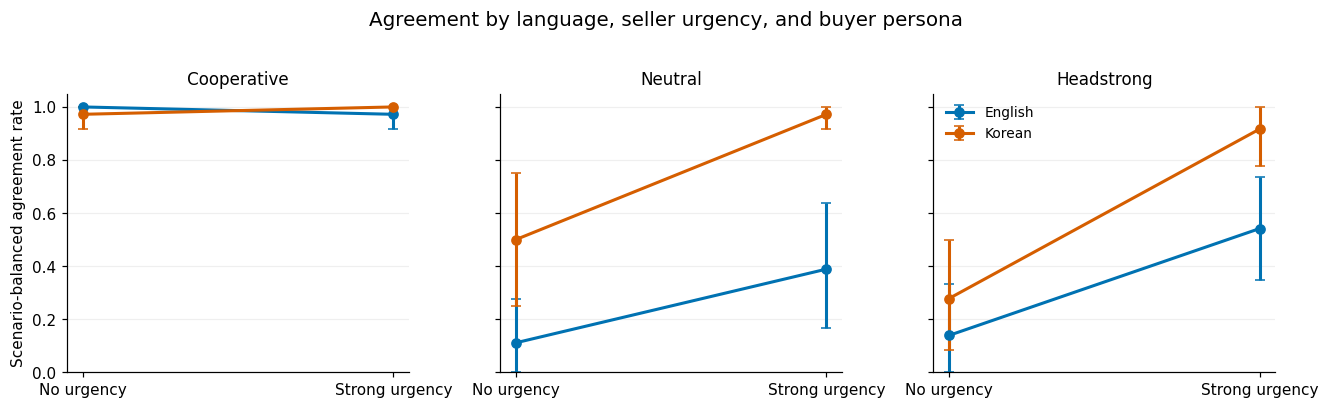

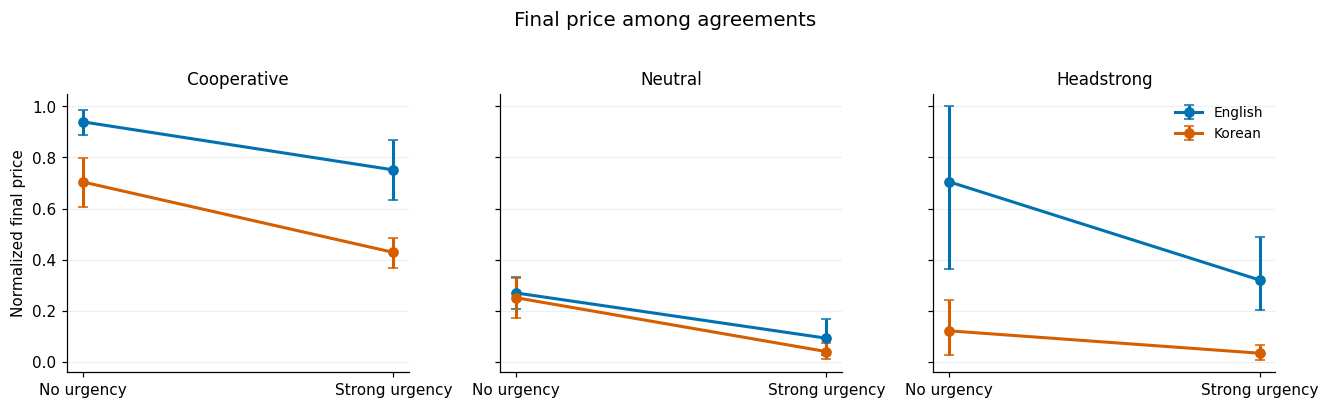

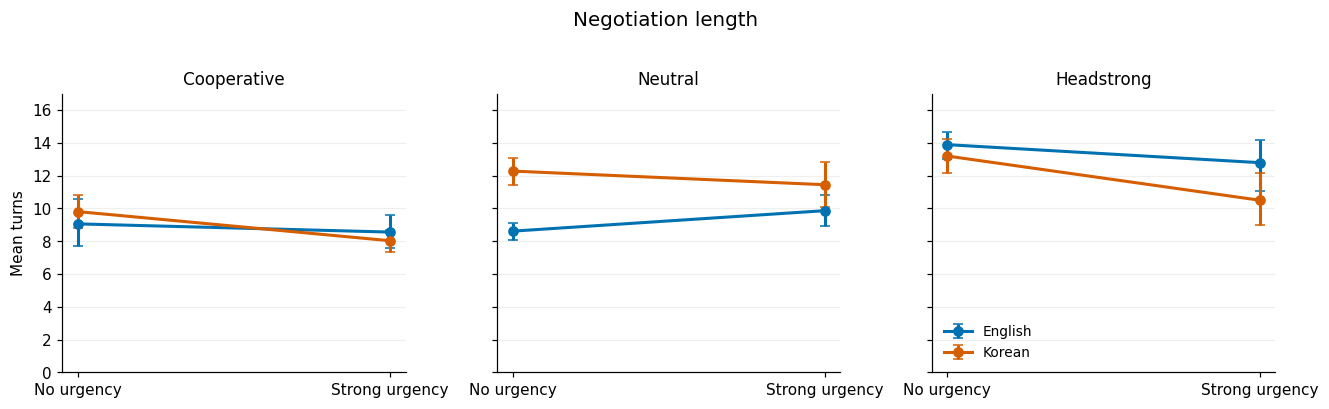

In [11]:
LANGUAGE_COLORS = {"en": "#0072B2", "ko": "#D55E00"}
LANGUAGE_LABELS = {"en": "English", "ko": "Korean"}
URGENCY_LABELS = {"none": "No urgency", "strong": "Strong urgency"}
PERSONA_LABELS = {
    "cooperative": "Cooperative",
    "neutral": "Neutral",
    "headstrong": "Headstrong",
}


def save_figure(fig, name: str) -> None:
    fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight", dpi=220)
    fig.savefig(
        FIGURE_DIR / f"{name}.pdf",
        bbox_inches="tight",
        metadata={"Creator": "full_experiment_analysis.ipynb", "CreationDate": None, "ModDate": None},
    )


def interaction_figure(metric: str, title: str, ylabel: str, filename: str, ylim=None):
    low_column = f"{metric}_ci_low"
    high_column = f"{metric}_ci_high"
    fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.6), sharey=True)
    x = np.arange(len(URGENCY_LEVELS))
    for axis, persona in zip(axes, PERSONAS):
        for language in LANGUAGES:
            subset = (
                primary_cell_summary.loc[
                    (primary_cell_summary["persona"] == persona)
                    & (primary_cell_summary["language"] == language)
                ]
                .set_index("urgency")
                .reindex(URGENCY_LEVELS)
            )
            values = subset[metric].to_numpy(dtype=float)
            errors = np.vstack(
                [
                    values - subset[low_column].to_numpy(dtype=float),
                    subset[high_column].to_numpy(dtype=float) - values,
                ]
            )
            axis.errorbar(
                x,
                values,
                yerr=errors,
                marker="o",
                linewidth=2,
                capsize=3,
                color=LANGUAGE_COLORS[language],
                label=LANGUAGE_LABELS[language],
            )
        axis.set_title(PERSONA_LABELS[persona])
        axis.set_xticks(x, [URGENCY_LABELS[value] for value in URGENCY_LEVELS])
        axis.grid(axis="y", alpha=0.2)
        if ylim is not None:
            axis.set_ylim(*ylim)
    axes[0].set_ylabel(ylabel)
    axes[-1].legend(frameon=False)
    fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


interaction_figure(
    "agreement_rate",
    "Agreement by language, seller urgency, and buyer persona",
    "Scenario-balanced agreement rate",
    "agreement_interactions",
    ylim=(0, 1.05),
)
interaction_figure(
    "normalized_final_price",
    "Final price among agreements",
    "Normalized final price",
    "final_price_interactions",
)
interaction_figure(
    "mean_turns",
    "Negotiation length",
    "Mean turns",
    "turn_length_interactions",
    ylim=(0, MAX_TURNS + 1),
)

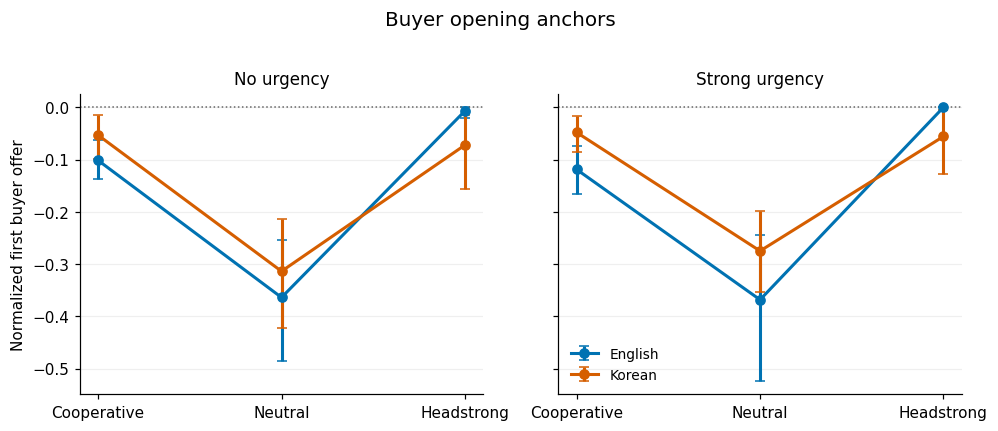

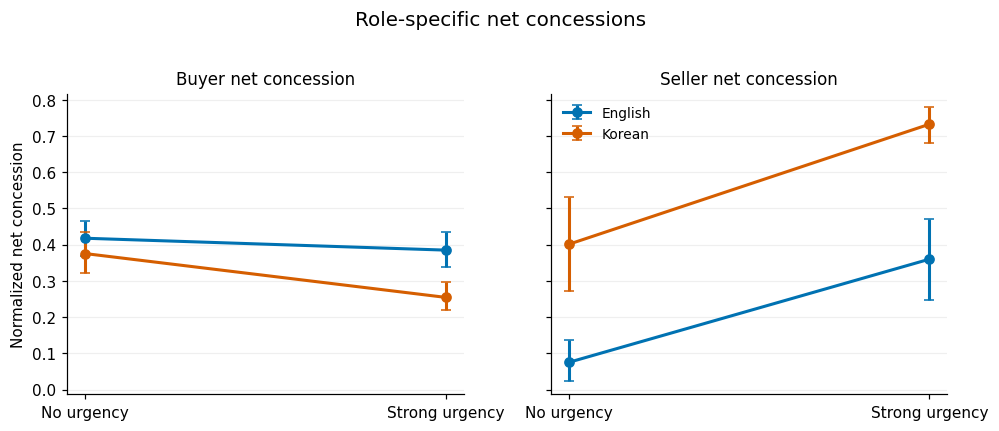

In [12]:
opening = behavior_cell_summary.loc[behavior_cell_summary["measure"] == "buyer_first_offer_norm"].copy()
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), sharey=True)
persona_x = np.arange(len(PERSONAS))
for axis, urgency in zip(axes, URGENCY_LEVELS):
    for language in LANGUAGES:
        subset = (
            opening.loc[(opening["urgency"] == urgency) & (opening["language"] == language)]
            .set_index("persona")
            .reindex(PERSONAS)
        )
        values = subset["estimate"].to_numpy(dtype=float)
        errors = np.vstack(
            [values - subset["ci_low"].to_numpy(dtype=float), subset["ci_high"].to_numpy(dtype=float) - values]
        )
        axis.errorbar(
            persona_x,
            values,
            yerr=errors,
            marker="o",
            linewidth=2,
            capsize=3,
            color=LANGUAGE_COLORS[language],
            label=LANGUAGE_LABELS[language],
        )
    axis.axhline(0, color="#666666", linewidth=1, linestyle=":")
    axis.set_title(URGENCY_LABELS[urgency])
    axis.set_xticks(persona_x, [PERSONA_LABELS[value] for value in PERSONAS])
    axis.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Normalized first buyer offer")
axes[-1].legend(frameon=False)
fig.suptitle("Buyer opening anchors", y=1.02, fontsize=13)
fig.tight_layout()
save_figure(fig, "buyer_opening_anchors")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), sharey=True)
for axis, (role, measure) in zip(
    axes,
    [("buyer", "buyer_net_concession_norm"), ("seller", "seller_net_concession_norm")],
):
    subset_measure = behavior_language_urgency.loc[behavior_language_urgency["measure"] == measure]
    for language in LANGUAGES:
        subset = subset_measure.loc[subset_measure["language"] == language].set_index("urgency").reindex(URGENCY_LEVELS)
        values = subset["estimate"].to_numpy(dtype=float)
        errors = np.vstack(
            [values - subset["ci_low"].to_numpy(dtype=float), subset["ci_high"].to_numpy(dtype=float) - values]
        )
        axis.errorbar(
            np.arange(2),
            values,
            yerr=errors,
            marker="o",
            linewidth=2,
            capsize=3,
            color=LANGUAGE_COLORS[language],
            label=LANGUAGE_LABELS[language],
        )
    axis.set_title(f"{role.title()} net concession")
    axis.set_xticks(np.arange(2), [URGENCY_LABELS[value] for value in URGENCY_LEVELS])
    axis.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Normalized net concession")
axes[-1].legend(frameon=False)
fig.suptitle("Role-specific net concessions", y=1.02, fontsize=13)
fig.tight_layout()
save_figure(fig, "net_concessions_language_urgency")
plt.show()

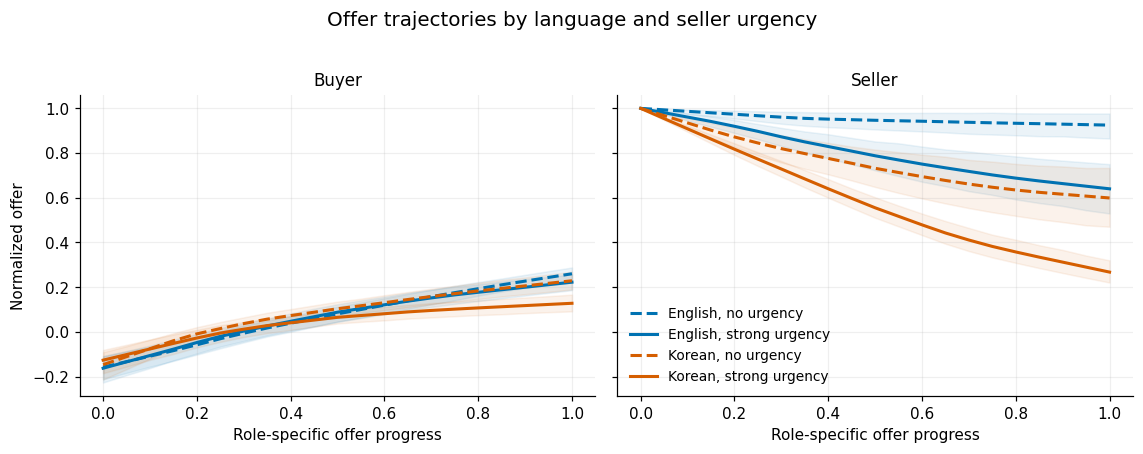

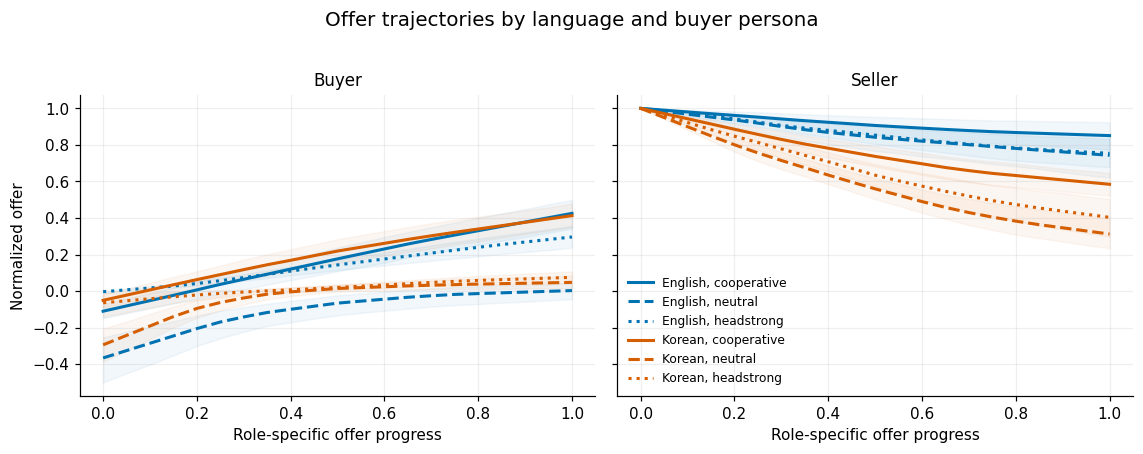

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharey=True)
urgency_styles = {"none": "--", "strong": "-"}
for axis, role in zip(axes, ROLES):
    subset_role = trajectory_language_urgency.loc[trajectory_language_urgency["role"] == role]
    for language in LANGUAGES:
        for urgency in URGENCY_LEVELS:
            curve = subset_role.loc[
                (subset_role["language"] == language) & (subset_role["urgency"] == urgency)
            ].sort_values("progress")
            axis.plot(
                curve["progress"],
                curve["estimate"],
                color=LANGUAGE_COLORS[language],
                linestyle=urgency_styles[urgency],
                linewidth=2,
                label=f"{LANGUAGE_LABELS[language]}, {URGENCY_LABELS[urgency].lower()}",
            )
            axis.fill_between(
                curve["progress"].to_numpy(dtype=float),
                curve["ci_low"].to_numpy(dtype=float),
                curve["ci_high"].to_numpy(dtype=float),
                color=LANGUAGE_COLORS[language],
                alpha=0.08,
            )
    axis.set_title(role.title())
    axis.set_xlabel("Role-specific offer progress")
    axis.grid(alpha=0.2)
axes[0].set_ylabel("Normalized offer")
axes[-1].legend(frameon=False, loc="best")
fig.suptitle("Offer trajectories by language and seller urgency", y=1.02, fontsize=13)
fig.tight_layout()
save_figure(fig, "offer_trajectories_language_urgency")
plt.show()

persona_styles = {"cooperative": "-", "neutral": "--", "headstrong": ":"}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharey=True)
for axis, role in zip(axes, ROLES):
    subset_role = trajectory_language_persona.loc[trajectory_language_persona["role"] == role]
    for language in LANGUAGES:
        for persona in PERSONAS:
            curve = subset_role.loc[
                (subset_role["language"] == language) & (subset_role["persona"] == persona)
            ].sort_values("progress")
            axis.plot(
                curve["progress"],
                curve["estimate"],
                color=LANGUAGE_COLORS[language],
                linestyle=persona_styles[persona],
                linewidth=2,
                label=f"{LANGUAGE_LABELS[language]}, {PERSONA_LABELS[persona].lower()}",
            )
            axis.fill_between(
                curve["progress"].to_numpy(dtype=float),
                curve["ci_low"].to_numpy(dtype=float),
                curve["ci_high"].to_numpy(dtype=float),
                color=LANGUAGE_COLORS[language],
                alpha=0.05,
            )
    axis.set_title(role.title())
    axis.set_xlabel("Role-specific offer progress")
    axis.grid(alpha=0.2)
axes[0].set_ylabel("Normalized offer")
axes[-1].legend(frameon=False, loc="best", fontsize=8)
fig.suptitle("Offer trajectories by language and buyer persona", y=1.02, fontsize=13)
fig.tight_layout()
save_figure(fig, "offer_trajectories_language_persona")
plt.show()

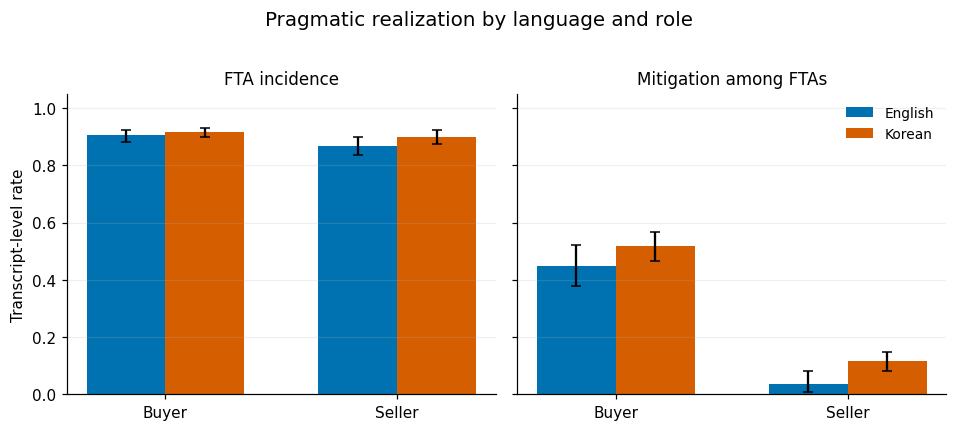

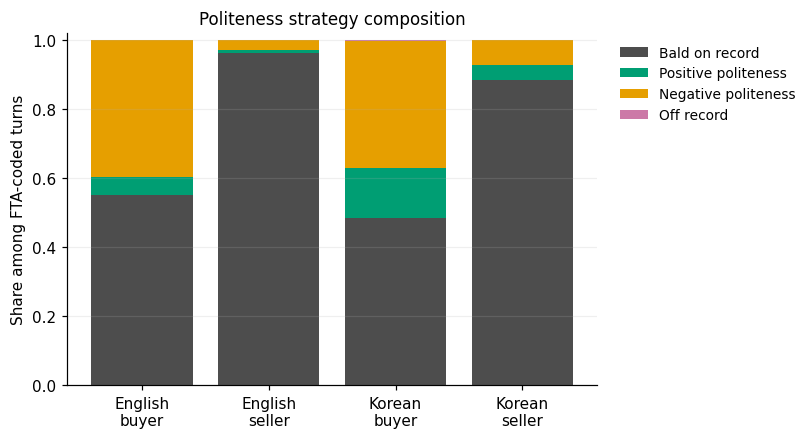

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.8), sharey=True)
x = np.arange(len(ROLES))
width = 0.34
for axis, measure, title in zip(
    axes,
    ["fta_rate", "mitigation_rate"],
    ["FTA incidence", "Mitigation among FTAs"],
):
    metric_rows = pragmatic_language_role.loc[pragmatic_language_role["measure"] == measure]
    for language_index, language in enumerate(LANGUAGES):
        subset = metric_rows.loc[metric_rows["language"] == language].set_index("role").reindex(ROLES)
        values = subset["estimate"].to_numpy(dtype=float)
        errors = np.vstack(
            [values - subset["ci_low"].to_numpy(dtype=float), subset["ci_high"].to_numpy(dtype=float) - values]
        )
        positions = x + (language_index - 0.5) * width
        axis.bar(
            positions,
            values,
            width=width,
            yerr=errors,
            capsize=3,
            color=LANGUAGE_COLORS[language],
            label=LANGUAGE_LABELS[language],
        )
    axis.set_title(title)
    axis.set_xticks(x, [role.title() for role in ROLES])
    axis.set_ylim(0, 1.05)
    axis.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Transcript-level rate")
axes[-1].legend(frameon=False)
fig.suptitle("Pragmatic realization by language and role", y=1.02, fontsize=13)
fig.tight_layout()
save_figure(fig, "pragmatic_rates_language_role")
plt.show()

strategy_measures = [f"{strategy}_share" for strategy in STRATEGIES]
strategy_labels = ["Bald on record", "Positive politeness", "Negative politeness", "Off record"]
strategy_colors = ["#4D4D4D", "#009E73", "#E69F00", "#CC79A7"]
group_labels = [f"{LANGUAGE_LABELS[language]}\n{role}" for language in LANGUAGES for role in ROLES]
fig, axis = plt.subplots(figsize=(7.5, 4.1))
bottoms = np.zeros(len(group_labels))
for measure, label, color in zip(strategy_measures, strategy_labels, strategy_colors):
    rows = pragmatic_language_role.loc[pragmatic_language_role["measure"] == measure]
    values = []
    for language in LANGUAGES:
        for role in ROLES:
            values.append(
                float(rows.loc[(rows["language"] == language) & (rows["role"] == role), "estimate"].iloc[0])
            )
    values = np.asarray(values)
    axis.bar(np.arange(len(values)), values, bottom=bottoms, color=color, label=label)
    bottoms += values
axis.set_xticks(np.arange(len(group_labels)), group_labels)
axis.set_ylabel("Share among FTA-coded turns")
axis.set_ylim(0, 1.02)
axis.grid(axis="y", alpha=0.2)
axis.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
axis.set_title("Politeness strategy composition")
fig.tight_layout()
save_figure(fig, "politeness_strategy_composition")
plt.show()

## 10. Export reproducible data, tables, and manifest

Row-level derived files contain actions, prices, and labels but omit raw
utterance text. The generated Markdown summary is an audit aid, not manuscript
prose, and retains the conditional-price and exploratory-analysis cautions.

In [15]:
def export_csv(frame: pd.DataFrame, path: Path) -> None:
    frame.to_csv(path, index=False, float_format="%.10g")


def export_latex(frame: pd.DataFrame, path: Path, columns: list[str] | None = None) -> None:
    output = frame if columns is None else frame[columns]
    output.to_latex(
        path,
        index=False,
        escape=True,
        float_format=lambda value: f"{value:.3f}",
        na_rep="--",
    )


turn_export_columns = [
    "transcript_id",
    "scenario_id",
    "condition_id",
    "language",
    "urgency",
    "persona",
    "repetition",
    "outcome",
    "turn_index",
    "turn_number",
    "role",
    "action",
    "price",
    "normalized_price",
    "is_fta",
    "strategy",
    "is_mitigated",
]

data_exports = {
    "attempt_manifest.csv": attempts_df,
    "exclusions.csv": exclusions_df,
    "transcript_metrics.csv": transcript_df,
    "turn_metrics.csv": turn_df[turn_export_columns],
    "pragmatic_transcript_metrics.csv": pragmatic_df,
    "trajectory_points.csv": trajectory_points,
}
table_exports = {
    "design_cell_counts.csv": cell_attempts,
    "primary_outcomes_by_cell.csv": primary_cell_summary,
    "primary_outcomes_marginal.csv": primary_marginal_summary,
    "factorial_contrasts.csv": factorial_contrasts,
    "headline_agreement_tests.csv": headline_agreement_tests,
    "behavior_by_cell.csv": behavior_cell_summary,
    "behavior_by_language_urgency.csv": behavior_language_urgency,
    "behavior_by_language_persona.csv": behavior_language_persona,
    "trajectory_summary.csv": trajectory_summary,
    "pragmatics_by_cell_role.csv": pragmatic_cell_summary,
    "pragmatics_by_language_role.csv": pragmatic_language_role,
    "pragmatics_by_outcome_language_role.csv": pragmatic_outcome_language_role,
}

for filename, frame in data_exports.items():
    export_csv(frame, DATA_DIR / filename)
for filename, frame in table_exports.items():
    export_csv(frame, TABLE_DIR / filename)

primary_latex_columns = CONDITION_COLUMNS + [
    "n_valid",
    "n_agreements",
    "agreement_rate",
    "abandonment_rate",
    "max_turn_rate",
    "mean_turns",
    "normalized_final_price",
]
headline_latex_columns = [
    "contrast_label",
    "estimate",
    "ci_low",
    "ci_high",
    "exact_p",
    "holm_p",
]
behavior_paper = behavior_language_urgency.loc[
    behavior_language_urgency["measure"].isin(
        [
            "buyer_first_offer_norm",
            "buyer_net_concession_norm",
            "seller_net_concession_norm",
            "terminal_gap_norm",
        ]
    )
].copy()
pragmatic_paper = pragmatic_language_role.loc[
    pragmatic_language_role["measure"].isin(
        ["fta_rate", "mitigation_rate", "bald_on_record_share", "negative_politeness_share"]
    )
].copy()

export_latex(cell_attempts, TABLE_DIR / "design_cell_counts.tex")
export_latex(primary_cell_summary, TABLE_DIR / "primary_outcomes_by_cell.tex", primary_latex_columns)
export_latex(headline_agreement_tests, TABLE_DIR / "headline_agreement_tests.tex", headline_latex_columns)
export_latex(behavior_paper, TABLE_DIR / "behavior_by_language_urgency.tex")
export_latex(pragmatic_paper, TABLE_DIR / "pragmatics_by_language_role.tex")
export_latex(factorial_contrasts, TABLE_DIR / "factorial_contrasts_appendix.tex")

quality_report = {
    "analysis_contract": {
        "expected_attempts": expected_attempts,
        "valid_transcripts": len(valid_df),
        "semantic_exclusions": len(exclusions_df),
        "bootstrap_samples": N_BOOTSTRAP,
        "bootstrap_seed": SEED,
        "confidence_level": CI_LEVEL,
        "max_turns": MAX_TURNS,
        "price_normalization": "(price - buyer_target) / (seller_target - buyer_target)",
    },
    "counts": {
        "transcript_files": len(transcript_paths),
        "judged_files": len(judged_paths),
        "validated_turns": len(turn_df),
        "outcomes": {name: int(count) for name, count in outcome_counts.items()},
        "judge_models": dict(judge_models),
    },
    "exclusions": exclusions_df.where(pd.notna(exclusions_df), None).to_dict("records"),
    "input_hashes": {
        "scenarios_json": sha256_file(SCENARIOS_PATH),
        "transcripts_combined": combined_sha256(transcript_paths, ROOT),
        "judged_combined": combined_sha256(judged_paths, ROOT),
    },
    "software": {
        "python_analysis_stack": "numpy/pandas/matplotlib",
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": plt.matplotlib.__version__,
    },
}
with (OUTPUT_DIR / "quality_report.json").open("w", encoding="utf-8") as handle:
    json.dump(quality_report, handle, ensure_ascii=True, indent=2, allow_nan=False)


def marginal_estimate(factor: str, level: str, measure: str) -> float:
    row = primary_marginal_summary.loc[
        (primary_marginal_summary["factor"] == factor)
        & (primary_marginal_summary["level"] == level)
        & (primary_marginal_summary["measure"] == measure)
    ]
    require(len(row) == 1, f"Missing marginal estimate for {factor}/{level}/{measure}")
    return float(row.iloc[0]["estimate"])


summary_lines = [
    "# Full experiment analysis summary",
    "",
    "This file is generated by `notebooks/full_experiment_analysis.ipynb`.",
    "It is an analysis audit aid, not manuscript-ready interpretation.",
    "",
    "## Dataset",
    "",
    f"- Attempted negotiations: {len(attempts_df)}",
    f"- Valid negotiations analyzed: {len(transcript_df)}",
    f"- Semantic parse-error exclusions: {len(exclusions_df)}",
    f"- Judged transcripts aligned: {len(judged_paths)}",
    f"- Agreements: {int(transcript_df['agreed'].sum())}",
    f"- Abandonments: {int(transcript_df['abandoned'].sum())}",
    f"- Turn-cap outcomes: {int(transcript_df['max_turn'].sum())}",
    "",
    "## Scenario-balanced descriptive estimates",
    "",
    f"- English agreement rate: {marginal_estimate('language', 'en', 'agreed'):.3f}",
    f"- Korean agreement rate: {marginal_estimate('language', 'ko', 'agreed'):.3f}",
    f"- No-urgency agreement rate: {marginal_estimate('urgency', 'none', 'agreed'):.3f}",
    f"- Strong-urgency agreement rate: {marginal_estimate('urgency', 'strong', 'agreed'):.3f}",
    "",
    "## Headline agreement contrasts",
    "",
    "| Contrast | Estimate | 95% CI | Exact p | Holm p |",
    "|---|---:|---:|---:|---:|",
]
for row in headline_agreement_tests.itertuples(index=False):
    summary_lines.append(
        f"| {row.contrast_label} | {row.estimate:.3f} | [{row.ci_low:.3f}, {row.ci_high:.3f}] "
        f"| {row.exact_p:.4f} | {row.holm_p:.4f} |"
    )
summary_lines.extend(
    [
        "",
        "## Interpretation constraints",
        "",
        "- Normalized final price is conditional on reaching agreement; non-agreements have no final price.",
        "- Pragmatic results are secondary transcript-level descriptions and are not a mediation analysis.",
        "- Three-way interactions are exploratory in this pilot-scale design.",
        f"- Report {len(attempts_df)} attempted negotiations and "
        f"{len(transcript_df)} valid negotiations analyzed.",
        "",
    ]
)
summary_path = OUTPUT_DIR / "analysis_summary.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

exported_files = sorted(path.relative_to(OUTPUT_DIR).as_posix() for path in OUTPUT_DIR.rglob("*") if path.is_file())
print(f"Exported {len(exported_files)} files under {OUTPUT_DIR}")
for filename in exported_files:
    print(f"  {filename}")

Exported 44 files under E:\polite-bargain\results\analysis
  analysis_summary.md
  data/attempt_manifest.csv
  data/exclusions.csv
  data/pragmatic_transcript_metrics.csv
  data/trajectory_points.csv
  data/transcript_metrics.csv
  data/turn_metrics.csv
  figures/agreement_interactions.pdf
  figures/agreement_interactions.png
  figures/buyer_opening_anchors.pdf
  figures/buyer_opening_anchors.png
  figures/final_price_interactions.pdf
  figures/final_price_interactions.png
  figures/net_concessions_language_urgency.pdf
  figures/net_concessions_language_urgency.png
  figures/offer_trajectories_language_persona.pdf
  figures/offer_trajectories_language_persona.png
  figures/offer_trajectories_language_urgency.pdf
  figures/offer_trajectories_language_urgency.png
  figures/politeness_strategy_composition.pdf
  figures/politeness_strategy_composition.png
  figures/pragmatic_rates_language_role.pdf
  figures/pragmatic_rates_language_role.png
  figures/turn_length_interactions.pdf
  figures

## 11. Headline audit view

The generated summary below makes the main estimates and caveats available for
later inspection without re-running the notebook. Detailed tables and figures
remain in `results/analysis/`.

In [16]:
display(Markdown((OUTPUT_DIR / "analysis_summary.md").read_text(encoding="utf-8")))

# Full experiment analysis summary

This file is generated by `notebooks/full_experiment_analysis.ipynb`.
It is an analysis audit aid, not manuscript-ready interpretation.

## Dataset

- Attempted negotiations: 432
- Valid negotiations analyzed: 430
- Semantic parse-error exclusions: 2
- Judged transcripts aligned: 430
- Agreements: 279
- Abandonments: 118
- Turn-cap outcomes: 33

## Scenario-balanced descriptive estimates

- English agreement rate: 0.525
- Korean agreement rate: 0.773
- No-urgency agreement rate: 0.500
- Strong-urgency agreement rate: 0.799

## Headline agreement contrasts

| Contrast | Estimate | 95% CI | Exact p | Holm p |
|---|---:|---:|---:|---:|
| Korean - English | 0.248 | [0.157, 0.347] | 0.0010 | 0.0039 |
| Language x urgency | 0.162 | [0.009, 0.329] | 0.1133 | 0.1133 |
| Language x (cooperative - neutral) | -0.486 | [-0.667, -0.306] | 0.0010 | 0.0039 |
| Language x (headstrong - neutral) | -0.229 | [-0.368, -0.083] | 0.0195 | 0.0391 |

## Interpretation constraints

- Normalized final price is conditional on reaching agreement; non-agreements have no final price.
- Pragmatic results are secondary transcript-level descriptions and are not a mediation analysis.
- Three-way interactions are exploratory in this pilot-scale design.
- Report 432 attempted negotiations and 430 valid negotiations analyzed.
